# Лабораторная работа E14 — Свой сигнал целиком: фильтр, окна, признаки, классификатор

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/e14.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/e14.html)**.

**Что разбираем.** В E13 мы научились проверять, годная ли запись. Теперь
прогоняем свой сигнал через весь конвейер, который до этого собирали по
кускам на чужих данных:

```
сырой сигнал → фильтр (20–450 Гц + режекция 50 Гц) → окна → признаки → LDA
```

Главный вопрос лабы — **зачем вообще нужен фильтр**. Ответ не такой простой,
как кажется: если грязь в тракте одна и та же при обучении и при проверке,
классификатор к ней приспосабливается, и фильтр как будто ничего не даёт. Вся
разница вылезает при **переносе** — когда обучили на одной записи, а работать
приходится на другой, снятой в других условиях. Ровно так живёт протез:
настроили утром, носят весь день.

Поэтому записей будет две: «калибровка» (чистая) и «рабочая» (с наводкой и
дрейфом). Записи, как и в E13, синтезируются — настоящего датчика в ноутбуке
нет. С появлением MyoWare меняется одна ячейка, та, что делает `X` и `y`.

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


In [2]:
ensure([("sklearn", "scikit-learn")])

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

Готово. Python 3.10.12


In [3]:
# ЯЧЕЙКА 2 · Признаки ЭМГ и нарезка на окна.
# Это «чёрный ящик» лабы: запусти один раз и дальше просто вызывай функции.
# Внутри — классический набор Хадгинса (Hudgins et al., 1993) плюс две
# частотные характеристики. Разбираться в реализации не нужно.

FS = 1000.0          # частота дискретизации записи, Гц
N_CH = 8             # каналов в браслете

TD_NAMES = ["MAV", "RMS", "WL", "ZC", "SSC"]
FREQ_NAMES = ["MDF", "MNF"]


def window_signal(X, y, fs=FS, win_ms=200.0, step_ms=100.0, keep=None, purity=0.6):
    """Режет запись X[N, C] с метками y[N] на скользящие окна.

    Метка окна — самый частый класс внутри него. Окно на стыке двух жестов
    (ни один класс не занимает purity доли окна) выбрасывается.
    Возвращает (windows[K, W, C], labels[K]).
    """
    width = int(round(win_ms / 1000.0 * fs))
    step = int(round(step_ms / 1000.0 * fs))
    keep = set(range(1, 8)) if keep is None else set(keep)
    wins, labs = [], []
    for start in range(0, len(X) - width + 1, step):
        chunk = y[start:start + width]
        values, counts = np.unique(chunk, return_counts=True)
        label = int(values[np.argmax(counts)])
        if label not in keep or counts.max() < purity * width:
            continue
        wins.append(X[start:start + width, :])
        labs.append(label)
    if not wins:
        return np.empty((0, width, X.shape[1])), np.empty((0,), int)
    return np.asarray(wins), np.asarray(labs, int)


def td_features(x, rel_eps=0.02):
    """Пять признаков Хадгинса по одному каналу.

    MAV — средний модуль (насколько сильно напряжена мышца);
    RMS — эффективная амплитуда (то же, что в лабе E4);
    WL  — суммарная длина кривой, мера «изрезанности»;
    ZC  — сколько раз сигнал пересёк ноль (грубая оценка частоты);
    SSC — сколько раз сменился знак наклона (тоже про частоту).

    ZC и SSC считают с мёртвой зоной rel_eps от уровня сигнала: без неё они
    считали бы дрожание нуля, а не настоящие колебания.
    """
    eps = rel_eps * np.sqrt(np.mean(x ** 2)) + 1e-12
    diff = np.diff(x)
    zc = int(np.sum((x[:-1] * x[1:] < 0) & (np.abs(diff) > eps)))
    d1, d2 = x[1:-1] - x[:-2], x[1:-1] - x[2:]
    ssc = int(np.sum((d1 * d2 > 0) & ((np.abs(d1) > eps) | (np.abs(d2) > eps))))
    return np.array([np.mean(np.abs(x)), np.sqrt(np.mean(x ** 2)),
                     np.sum(np.abs(diff)), zc, ssc], float)


def freq_features(x, fs=FS):
    """MDF и MNF — медианная и средняя частоты спектра мощности канала.

    MDF делит энергию спектра пополам, MNF — центр масс спектра. Обе падают
    при утомлении мышцы, поэтому их считают вместе с амплитудными.
    """
    x = x - np.mean(x)
    power = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    total = power.sum() + 1e-24
    cumulative = np.cumsum(power)
    mdf = freqs[np.searchsorted(cumulative, cumulative[-1] / 2)]
    return np.array([mdf, np.sum(freqs * power) / total], float)


def features_window(win, fs=FS):
    """Одно окно win[W, C] → один длинный вектор чисел: 7 признаков на канал."""
    return np.concatenate([
        np.concatenate([td_features(win[:, c]), freq_features(win[:, c], fs)])
        for c in range(win.shape[1])])


def feature_names(n_ch=N_CH):
    """Имена координат вектора признаков — в том же порядке, что и значения."""
    return ["ch%d_%s" % (c + 1, nm)
            for c in range(n_ch) for nm in TD_NAMES + FREQ_NAMES]


def features_of(X, y, fs=FS, win_ms=200.0, step_ms=100.0, keep=None):
    """Запись → матрица признаков. Возвращает (Xf[K, D], labels[K])."""
    wins, labs = window_signal(X, y, fs, win_ms, step_ms, keep)
    return np.array([features_window(w, fs) for w in wins]), labs

In [4]:
# ЯЧЕЙКА · Свой сигнал: имитация сенсора, которого нет.
# Честно: настоящего ЭМГ-датчика у нас в ноутбуке нет, поэтому «свою» запись
# мы синтезируем. Модель простая и физически осмысленная: ЭМГ — это шум,
# профильтрованный в полосу 20–450 Гц, амплитуда которого следует за усилием
# мышцы. Сюда же добавляются болезни реального тракта: наводка 50 Гц, дрейф
# нуля и постоянное смещение. Когда появится железо, меняется только источник
# сигнала — вся остальная обработка остаётся той же.

from scipy.signal import butter, filtfilt, iirnotch

FS = 1000.0                  # частота дискретизации, Гц
BAND = (20.0, 450.0)         # рабочая полоса ЭМГ


def bandpass(x, fs=FS, lo=BAND[0], hi=BAND[1], order=4):
    """Полосовой фильтр Баттерворта: пропускает только полосу ЭМГ."""
    nyquist = fs / 2.0
    b, a = butter(order, [lo / nyquist, min(hi, nyquist * 0.99) / nyquist],
                  btype="band")
    return filtfilt(b, a, x)


def notch(x, fs=FS, f0=50.0, q=30.0):
    """Режекторный фильтр: вырезает узкую полосу вокруг f0 (сетевая наводка)."""
    b, a = iirnotch(f0 / (fs / 2.0), q)
    return filtfilt(b, a, x)


def rms(x):
    """Эффективная амплитуда сигнала (постоянная составляющая не учитывается)."""
    x = np.asarray(x, float)
    return float(np.sqrt(np.mean((x - np.mean(x)) ** 2)))


def spectrum(x, fs=FS):
    """Амплитудный спектр окна: (частоты, амплитуды)."""
    x = np.asarray(x, float) - np.mean(x)
    return (np.fft.rfftfreq(len(x), d=1.0 / fs),
            np.abs(np.fft.rfft(x * np.hanning(len(x)))))


def power_fraction(x, band, fs=FS):
    """Какая доля энергии сигнала лежит в полосе band = (низ, верх), в герцах."""
    freqs, amplitude = spectrum(x, fs)
    power = amplitude ** 2
    inside = (freqs >= band[0]) & (freqs <= band[1])
    return float(np.sum(power[inside]) / (np.sum(power) + 1e-24))


def band_fraction(x, fs=FS, band=BAND):
    """Доля энергии в рабочей полосе ЭМГ. У чистого сигнала с мышцы — почти вся."""
    return power_fraction(x, band, fs)


def blocks(pattern, seconds):
    """Сценарий усилия из блоков равной длины: [0, 1, 0, 0.6] → покой, сжатие, ..."""
    span = seconds / len(pattern)

    def level(t):
        return pattern[min(len(pattern) - 1, int(t / span))]

    return level


def synth_emg(level_fn, seconds, fs=FS, seed=0, rest=0.05,
              mains=0.0, drift=0.0, offset=0.0, ramp_ms=150.0):
    """«Записать» свой сигнал. Возвращает (x[N], усилие мышцы[N]).

    level_fn(t) задаёт усилие от 0 до 1 в момент t (секунды). Скачки усилия
    сглаживаются за ramp_ms — мышца не включается мгновенно, и вторым значением
    возвращается именно сглаженное усилие: то, что мышца делала на самом деле.
    rest — остаточная активность в покое, mains/drift/offset — грязь тракта в
    тех же единицах.
    """
    rng = np.random.default_rng(seed)
    n = int(seconds * fs)
    t = np.arange(n) / fs

    shaped = bandpass(rng.standard_normal(n), fs)
    shaped /= np.sqrt(np.mean(shaped ** 2)) + 1e-12

    level = np.array([float(level_fn(v)) for v in t])
    width = max(1, int(ramp_ms / 1000.0 * fs))
    kernel = np.hanning(width)
    envelope = np.convolve(level, kernel / kernel.sum(), mode="same")

    x = shaped * (rest + envelope)
    x = x + mains * np.sin(2 * np.pi * 50.0 * t)
    x = x + drift * np.sin(2 * np.pi * 0.7 * t) + offset
    return x, envelope


def add_artifacts(x, mask=None, fs=FS, count=6, amplitude=0.8, ms=60.0, seed=0,
                  gap_ms=500.0):
    """Короткие всплески: подёргивание мышцы, шевеление электрода, толчок кабеля.

    mask — где всплески разрешены (булев массив длины x), gap_ms — минимальный
    промежуток между соседними всплесками, чтобы они не слипались в один.
    Возвращает (сигнал с всплесками, позиции всплесков в отсчётах).
    """
    rng = np.random.default_rng(seed)
    width = int(ms / 1000.0 * fs)
    gap = int(gap_ms / 1000.0 * fs)
    allowed = np.arange(len(x) - width) if mask is None \
        else np.flatnonzero(mask[:len(x) - width])
    if len(allowed) == 0 or count == 0:
        return np.array(x, float), np.array([], int)

    positions = []
    for start in rng.permutation(allowed):
        if all(abs(int(start) - p) >= gap for p in positions):
            positions.append(int(start))
        if len(positions) == count:
            break

    out = np.array(x, float)
    burst = bandpass(rng.standard_normal(width), fs) * np.hanning(width)
    burst = burst / (np.sqrt(np.mean(burst ** 2)) + 1e-12) * amplitude
    for start in positions:
        out[start:start + width] += burst
    return out, np.sort(np.array(positions, int))

In [5]:
# ЯЧЕЙКА · Матрица ошибок: печать и картинка.
# Тоже «чёрный ящик»: запусти один раз, дальше просто вызывай.

def confusion(y_true, y_pred, labels):
    """Матрица ошибок вручную: строки — истина, столбцы — предсказание."""
    index = {int(l): i for i, l in enumerate(labels)}
    matrix = np.zeros((len(labels), len(labels)), int)
    for t, p in zip(y_true, y_pred):
        matrix[index[int(t)], index[int(p)]] += 1
    return matrix


def accuracy(y_true, y_pred):
    """Доля верно угаданных окон."""
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))


def print_confusion(matrix, labels, title="Матрица ошибок"):
    """Та же матрица текстом, в процентах по строкам."""
    names = [GESTURE_NAMES[int(l)] for l in labels]
    print(title + " (%, строка — истина):")
    print("   %-12s" % "" + "".join("%9s" % n[:8] for n in names))
    for name, row in zip(names, matrix):
        total = row.sum() + 1e-12
        print("   %-12s" % name[:12] + "".join("%9.1f" % (100.0 * v / total) for v in row))


def plot_confusion(matrix, labels, title="Матрица ошибок"):
    """Картинка матрицы: по диагонали — верные ответы, вне её — путаница."""
    names = [GESTURE_NAMES[int(l)] for l in labels]
    share = matrix / (matrix.sum(axis=1, keepdims=True) + 1e-12)
    fig, ax = plt.subplots(figsize=(1.0 + 1.1 * len(labels), 0.9 + 1.0 * len(labels)))
    image = ax.imshow(share, cmap="Blues", vmin=0, vmax=1)
    ax.set(xticks=range(len(labels)), yticks=range(len(labels)),
           xlabel="предсказано", ylabel="истина", title=title)
    ax.set_xticklabels(names, rotation=30, ha="right", fontsize=9)
    ax.set_yticklabels(names, fontsize=9)
    ax.grid(False)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, "%d" % matrix[i, j], ha="center", va="center", fontsize=9,
                    color="white" if share[i, j] > 0.5 else "black")
    fig.colorbar(image, ax=ax, fraction=0.045, label="доля строки")
    fig.tight_layout()
    plt.show()

## Ячейка 5 · Две записи: калибровочная и рабочая

Сценарий обеих одинаковый: покой — сжатие — сильное сжатие, четыре круга.
Отличаются они только состоянием тракта. Калибровочная снята аккуратно, в
рабочей электрод держится хуже: наводка 50 Гц, дрейф нуля и смещение.

In [6]:
SECONDS = 36.0
GESTURES = [0, 1, 2] * 4                 # четыре круга покой → сжатие → сильное
CLASSES = [0, 1, 2]
EFFORT = {0: 0.0, 1: 0.55, 2: 1.0}       # усилие мышцы для каждого класса

# Имена классов этой лабы: их берут печать и картинка матрицы ошибок.
GESTURE_NAMES = {0: "покой", 1: "сжатие", 2: "сильн. сжатие"}


def make_record(seed, mains, drift, offset):
    """«Записать» сеанс: возвращает (сигнал, метки классов по отсчётам)."""
    signal, _ = synth_emg(blocks([EFFORT[g] for g in GESTURES], SECONDS),
                          SECONDS, seed=seed, rest=0.02,
                          mains=mains, drift=drift, offset=offset)
    labels = np.repeat(np.array(GESTURES), len(signal) // len(GESTURES))
    return signal, labels[:len(signal)]


calib, calib_y = make_record(3, mains=0.02, drift=0.02, offset=0.00)
work, work_y = make_record(5, mains=0.50, drift=0.35, offset=0.05)


def dirt(name, signal):
    """Три числа из E13: сеть, дрейф, смещение нуля."""
    print("%-14s 50 Гц: %4.1f %% | ниже 20 Гц: %4.1f %% | смещение: %+.3f"
          % (name, 100 * power_fraction(signal, (48.0, 52.0)),
             100 * power_fraction(signal, (0.0, 20.0)), np.mean(signal)))


print("Каждая запись: %.0f с при %.0f Гц, %d блоков по %.0f с.\n"
      % (SECONDS, FS, len(GESTURES), SECONDS / len(GESTURES)))
dirt("калибровка:", calib)
dirt("рабочая:", work)

Каждая запись: 36 с при 1000 Гц, 12 блоков по 3 с.

калибровка:    50 Гц:  1.1 % | ниже 20 Гц:  0.2 % | смещение: +0.000
рабочая:       50 Гц: 19.6 % | ниже 20 Гц:  9.6 % | смещение: +0.052


## Ячейка 6 · Фильтр: две ступени

**Полосовой 20–450 Гц** выбрасывает то, чего у ЭМГ быть не может: дрейф и
смещение снизу, высокочастотный мусор сверху. **Режекторный на 50 Гц**
добивает сетевую наводку — она сидит внутри рабочей полосы, и полосовой её не
трогает. Это ровно то, что мы измеряли в E13 узкими проверками.

In [7]:
def clean(signal, fs=FS):
    """Полный фильтр тракта: полоса 20–450 Гц, затем режекция сети."""
    return notch(bandpass(signal, fs), fs)


work_bp = bandpass(work, FS)
work_clean = notch(work_bp, FS)
calib_clean = clean(calib)

dirt("рабочая:", work)
dirt("+ полосовой:", work_bp)
dirt("+ режекция:", work_clean)
print("\nПолосовой убрал дрейф и смещение, а доля 50 Гц после него даже выросла:")
print("он вырезал всё вокруг, но саму наводку не тронул — это работа режекции.")

рабочая:       50 Гц: 19.6 % | ниже 20 Гц:  9.6 % | смещение: +0.052
+ полосовой:   50 Гц: 22.0 % | ниже 20 Гц:  0.0 % | смещение: +0.000
+ режекция:    50 Гц:  0.4 % | ниже 20 Гц:  0.0 % | смещение: +0.000

Полосовой убрал дрейф и смещение, а доля 50 Гц после него даже выросла:
он вырезал всё вокруг, но саму наводку не тронул — это работа режекции.


## Ячейка 7 · Три стадии конвейера глазами

Смотрим полторы секунды рабочей записи на границе «покой → сжатие»: там видно
и грязь, и момент включения мышцы.

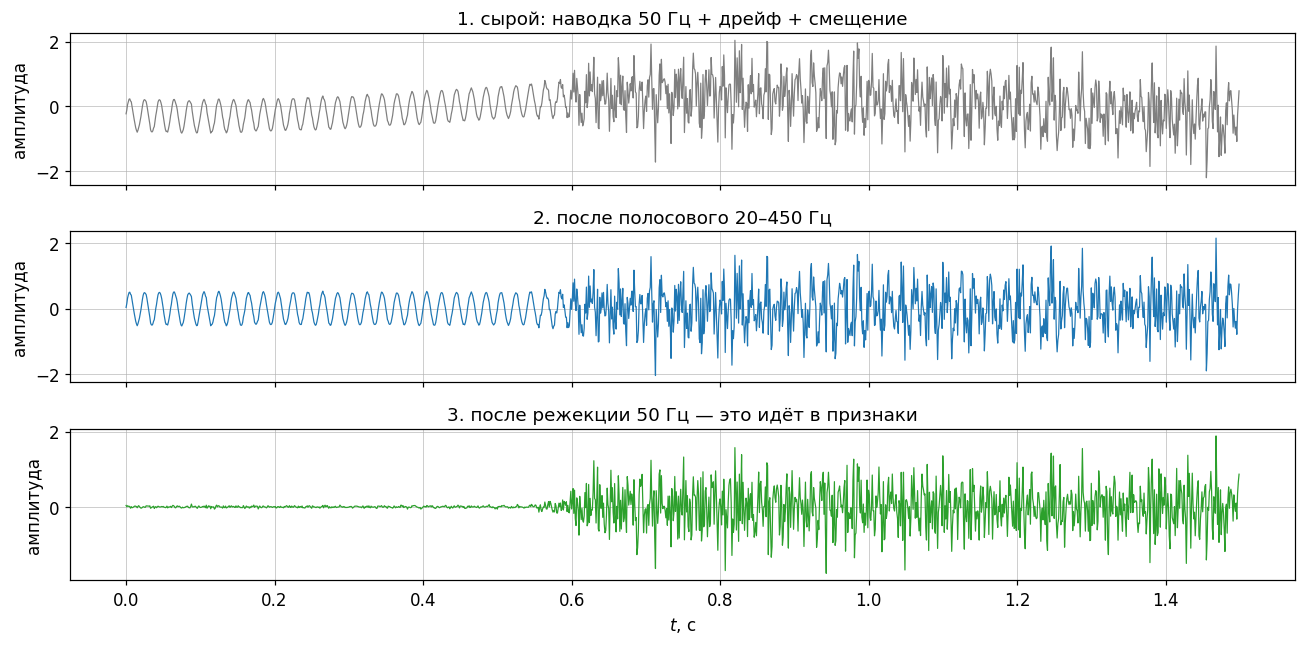

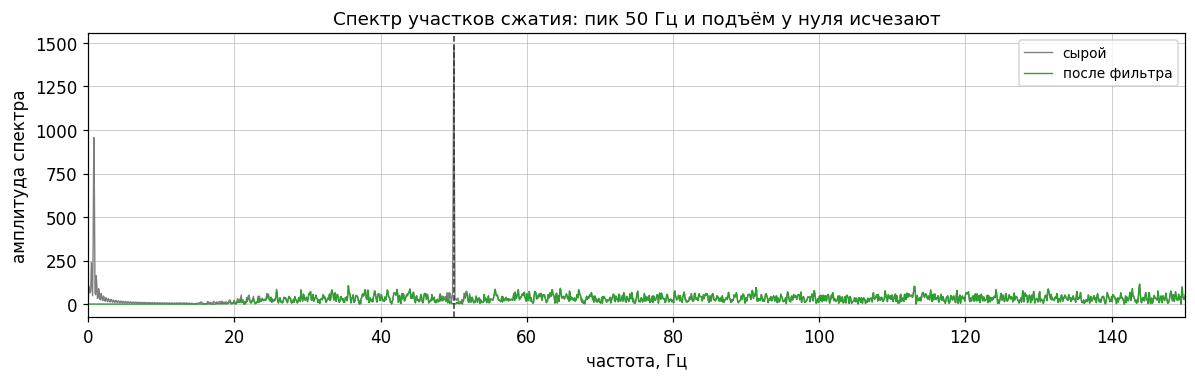

In [8]:
segment = slice(int(2.4 * FS), int(3.9 * FS))
time = np.arange(segment.stop - segment.start) / FS

stages = [(work, "1. сырой: наводка 50 Гц + дрейф + смещение", "tab:gray"),
          (work_bp, "2. после полосового 20–450 Гц", "tab:blue"),
          (work_clean, "3. после режекции 50 Гц — это идёт в признаки", "tab:green")]

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 6.0))
for ax, (signal, title, color) in zip(axes, stages):
    ax.plot(time, signal[segment], lw=0.8, color=color)
    ax.set(title=title, ylabel="амплитуда")
axes[-1].set_xlabel("$t$, с")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 3.6))
for signal, label, color in [(work, "сырой", "tab:gray"),
                             (work_clean, "после фильтра", "tab:green")]:
    freqs, amplitude = spectrum(signal[work_y == 1], FS)
    ax.plot(freqs, amplitude, lw=0.9, color=color, label=label)
ax.axvline(50.0, color="#333", ls="--", lw=1.0)
ax.set(xlabel="частота, Гц", ylabel="амплитуда спектра", xlim=(0, 150),
       title="Спектр участков сжатия: пик 50 Гц и подъём у нуля исчезают")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Ячейка 8 · Окна, признаки и два способа проверить

Дальше — то же, что в E7 на чужих данных: нарезать на окна, посчитать
признаки, обучить LDA. Сигнал одноканальный, поэтому вектор признаков
короткий: 7 чисел (MAV, RMS, WL, ZC, SSC, MDF, MNF) вместо 56 у браслета.

Проверяем двумя способами:

* **внутри одной записи** — обучающие и проверочные окна берём из рабочей
  записи вперемешку. Так делают чаще всего, и это самая обманчивая проверка;
* **переносом** — учим на калибровочной записи, проверяем на рабочей. Это то,
  что реально ждёт протез.

In [9]:
WIN_MS, STEP_MS = 200.0, 100.0
TEST_SHARE = 0.4


def to_features(signal, labels):
    """Сигнал → (матрица признаков [K, 7], метки окон [K])."""
    windows, window_labels = window_signal(signal.reshape(-1, 1), labels, FS,
                                           WIN_MS, STEP_MS, keep=CLASSES)
    return np.array([features_window(w, FS) for w in windows]), window_labels


def fit_lda(features, labels):
    return make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()).fit(
        features, labels)


def inside_one_record(features, labels):
    """Случайное деление окон одной записи на обучение и проверку."""
    order = np.random.default_rng(3).permutation(len(labels))
    split = int((1.0 - TEST_SHARE) * len(order))
    train, test = order[:split], order[split:]
    predicted = fit_lda(features[train], labels[train]).predict(features[test])
    return accuracy(labels[test], predicted), confusion(labels[test], predicted, CLASSES)


def transfer(train_features, train_labels, test_features, test_labels):
    """Обучение на одной записи, проверка целиком на другой."""
    predicted = fit_lda(train_features, train_labels).predict(test_features)
    return accuracy(test_labels, predicted), confusion(test_labels, predicted, CLASSES)


results = {}
for name, calib_signal, work_signal in [("без фильтра", calib, work),
                                        ("с фильтром", calib_clean, work_clean)]:
    calib_features, calib_labels = to_features(calib_signal, calib_y)
    work_features, work_labels = to_features(work_signal, work_y)
    results[name] = {
        "внутри записи": inside_one_record(work_features, work_labels),
        "перенос": transfer(calib_features, calib_labels, work_features, work_labels),
    }

print("Окон в рабочей записи: %d, признаков в окне: 7.\n" % len(work_labels))
print("%-14s%16s%16s" % ("", "внутри записи", "перенос"))
for name, pair in results.items():
    print("%-14s%16.3f%16.3f"
          % (name, pair["внутри записи"][0], pair["перенос"][0]))

Окон в рабочей записи: 348, признаков в окне: 7.

                 внутри записи         перенос
без фильтра              1.000           0.678
с фильтром               1.000           1.000


## Ячейка 9 · Куда именно уезжает классификатор без фильтра

Числа выше говорят, что при переносе без фильтра всё плохо. Матрицы ошибок
говорят, **как** плохо: важно не только сколько ошибок, но и в какую сторону.

Перенос без фильтра (%, строка — истина):
                   покой   сжатие сильн. с
   покой             6.0     94.0      0.0
   сжатие            0.0     97.4      2.6
   сильн. сжати      0.0      0.0    100.0

Перенос с фильтром (%, строка — истина):
                   покой   сжатие сильн. с
   покой           100.0      0.0      0.0
   сжатие            0.0    100.0      0.0
   сильн. сжати      0.0      0.0    100.0


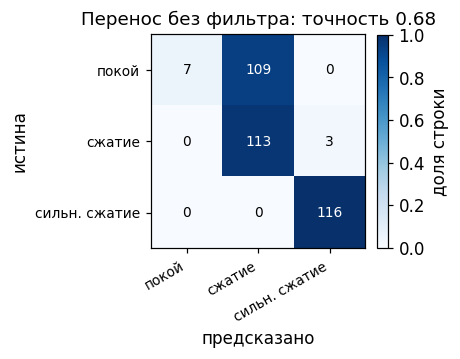

In [10]:
print_confusion(results["без фильтра"]["перенос"][1], CLASSES,
                "Перенос без фильтра")
print()
print_confusion(results["с фильтром"]["перенос"][1], CLASSES,
                "Перенос с фильтром")

plot_confusion(results["без фильтра"]["перенос"][1], CLASSES,
               "Перенос без фильтра: точность %.2f"
               % results["без фильтра"]["перенос"][0])

Ошибка не случайная: покой почти целиком уезжает в «сжатие». Причина простая
— наводка добавляет к рабочей записи постоянную амплитуду, и окна покоя
становятся по амплитуде похожи на слабое сжатие из калибровки. Классификатор
не сломан, он честно применяет выученное правило к сигналу, который сместился
под ним целиком. Фильтр возвращает записи в одну шкалу, и правило снова
работает.

**Честно про цифры.** На синтетике фильтрованный вариант вылечивается
полностью, до единицы: грязь в модели ровно та, которую фильтр умеет резать.
На живом сигнале так не бывает — там остаются движение электрода, изменение
сопротивления кожи и утомление мышцы, и часть разрыва между записями фильтр
не закроет. Правильный вывод из лабы не «фильтр всё чинит», а «без фильтра
перенос не имеет шансов, с фильтром — имеет».

И отдельно: проверка «внутри одной записи» показала одинаковый результат в
обоих случаях. Она измеряет не то, что нужно, и на ней легко убедить себя,
что фильтр не нужен.

## Задания

1. Приведи таблицу из четырёх точностей и обе матрицы переноса. Объясни, что
   именно измеряет каждая из двух проверок.
2. Прогони `mains` рабочей записи = 0.05, 0.15, 0.3, 0.6 и построй две кривые
   точности переноса от уровня наводки — с фильтром и без. С какого уровня
   нефильтрованный вариант становится бесполезным?
3. Оставь в фильтре только полосовой 20–450 Гц, без режекции. Насколько он
   справляется сам? Свяжи ответ с тем, что 50 Гц лежит внутри полосы.